In [4]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

In [5]:
import re
import json
import pandas as pd

In [6]:
pd.set_option('display.max_colwidth', 50)

with open('../../data/raw/books_sample.json', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(3)

레코드 수: 103,482
컬럼 수: 15


,isbn,title,author,publisher,publish_date,page,price,simple_intro,book_intro,cate_depth1,kcid,book_index,pub_review,ori_cover_s,author_intro
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,4000,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,[유아],[011002002],NaN,NaN,NaN,NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,15000,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.여전히 주말이면 산을 찾아 가족은...,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,"[여행, 건강/취미]","[015003003, 015003005, 016002010]",51. 전북 정읍 내장산\n52. 서울 노원 수락산\n53. 충북 담양 금수산\n5...,산에 왜 갔지 ? 그 두 번째 이야기\n★ 준비 걸음 : 아빠 노릇 제대로 못했으니...,https://image.aladin.co.kr/product/3917/39/cov...,NaN
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,16000,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,[종교],[010006],NaN,NaN,https://image.aladin.co.kr/product/29747/36/co...,NaN


### 컬럼 선택

In [7]:
cols = ['isbn', 'title', 'author', 'publisher', 'publish_date', 'page', 'book_intro', 'pub_review', 'cate_depth1', 'ori_cover_s']
df = df[cols]

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(5)

레코드 수: 103,482
컬럼 수: 10


,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,NaN,[유아],NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,산에 왜 갔지 ? 그 두 번째 이야기\n★ 준비 걸음 : 아빠 노릇 제대로 못했으니...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,NaN,[종교],https://image.aladin.co.kr/product/29747/36/co...
3,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다!\n중국 누적 ...",[소설],https://image.aladin.co.kr/product/24410/85/co...
4,9788966308019,보건프로그램 개발 및 평가,안양희 저,현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,NaN,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...


### ISBN 13자리 미만 삭제 
- 1건 삭제

In [8]:
df = df[df['isbn'].astype(str).str.len() >= 13]

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')
df.head(5)

레코드 수: 103,481
컬럼 수: 10


,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s
0,9788931908527,알라딘 - 월트디즈니명작,지경사 편집부,지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,NaN,[유아],NaN
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"이상훈, 고광문, 이은빈, 이은찬 공저",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다.\n여전히 주말이면 산을 찾아 가...,산에 왜 갔지 ? 그 두 번째 이야기\n★ 준비 걸음 : 아빠 노릇 제대로 못했으니...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...
2,8830000002603,계묘년 생기복덕 책력(대),편집부 저,보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,NaN,[종교],https://image.aladin.co.kr/product/29747/36/co...
3,9788963717715,부요황후 1,천하귀원 저/김지혜 역,파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다!\n중국 누적 ...",[소설],https://image.aladin.co.kr/product/24410/85/co...
4,9788966308019,보건프로그램 개발 및 평가,안양희 저,현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,NaN,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...


### 텍스트 전처리

#### book_intro
- 한글, 영어, 숫자 포함. 그 외 언어는 제외
- 장식 기호 제거
- 반복 구두점 정리
    - ex) “…”, “!!!”
- 연속 공백 정리
- 줄바꿈(”\n”) 제거 후 공백 치환

In [9]:
df[df['book_intro'].apply(lambda x: bool(re.search(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', str(x))))][['isbn', 'title', 'book_intro']].head(5)

,isbn,title,book_intro
3,9788963717715,부요황후 1,"중국 누적 조회 수 100억 돌파, 드라마 [부요황후] 원작 소설\n유머 넘치는 문..."
7,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아...
8,9788928306619,우공비 과학 4-1 - 2013,- 독자대상 : 초등학교 4학년\n- 구성 : 이론 + 문제\n- 특징 :\n① 풍...
9,9788930081955,사회통계방법론 - SPSS/PC WINDOWS 12.0,"통계학 전공서. 이 책은 χ² , t 검증, 일원변량방법, 다원변량방법, 단순회귀분..."
11,9791193277225,초등 저학년 교과연계 문해력 필독서 세트,초등학교 1~2학년 교과과정 연계 도서 세트입니다.


In [10]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return text
    
    # 줄바꿈 → 공백
    text = re.sub(r'\n+', ' ', text)

    # 한글, 영어, 숫자, 기본 구두점, 공백만 유지
    text = re.sub(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', ' ', text)
    
    # 반복 구두점 정리
    text = re.sub(r'[.]{2,}', '.', text)
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    
    # 연속 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [11]:
df['book_intro'] = df['book_intro'].apply(clean_text)
df['pub_review'] = df['pub_review'].apply(clean_text)

In [12]:
# 한글, 영어 외 + 특수문자 존재하는지 확인

df[df['book_intro'].apply(lambda x: bool(re.search(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', str(x))))][['isbn', 'title', 'book_intro']].head(5)

,isbn,title,book_intro


In [13]:
# 한글, 영어 외 + 특수문자 존재하는지 확인

df[df['pub_review'].apply(lambda x: bool(re.search(r'[^\uAC00-\uD7A3a-zA-Z0-9\s.,!?\'\"()\-]', str(x))))][['isbn', 'title', 'book_intro']].head(5)

,isbn,title,book_intro


### author 컬럼 분리
- 한 컬럼 안에 [저, 역, 감수, 공저]가 같이 존재함
- 컬럼 나누기 [”author”, “translator”, “supervisor”]

In [14]:
df['ori_author'] = df['author']

In [15]:
def parse_author(text):
    if not isinstance(text, str):
        return [], [], []
    
    author, translator, supervisor = [], [], []
    
    # '외 N명' 제거
    text = re.sub(r'\s*외\s*\d+명', '', text)
    
    # 복합 태그 임시 치환
    text = re.sub(r'글,\s*그림', '글그림', text)
    text = re.sub(r'글,\s*기획', '글기획', text)
    text = re.sub(r'글,\s*만화', '글만화', text)
    text = re.sub(r'기획,\s*제작', '기획제작', text)
    
    role_pattern = r'(공저|편저|편역|공역|저|역|감수|자문|글그림|글기획|글만화|기획제작|글|그림|만화|기획|제작|편)$'
    
    # '/' 기준으로 역할별 세그먼트 분리
    segments = text.split('/')
    
    for seg in segments:
        seg = seg.strip()
        
        # ',' 기준으로 분리
        parts = [p.strip() for p in seg.split(',') if p.strip()]
        
        last_name = None  # 이전 이름 저장 (태그 단독 케이스 대비)
        
        # 각 part에서 역할 태그 추출 후 이름 파싱
        for part in parts:
            tag_match = re.search(role_pattern, part)
            
            if tag_match:
                tag = tag_match.group()
                name = part[:tag_match.start()].strip()
                
                # 이름 없는 태그 단독 케이스 → 이전 이름 재사용
                if not name:
                    name = last_name
                
                if not name:
                    continue
                
                last_name = name  # 이름 업데이트
                
                if tag in ('역', '공역', '편역'):
                    translator.append(name)
                elif tag in ('감수', '자문'):
                    supervisor.append(name)
                else:  # 저, 공저, 편저, 글그림, 글기획, 글만화, 기획제작, 글, 그림, 만화, 기획, 제작
                    author.append(name)
            else:
                # 태그 없는 경우 → author
                author.append(part)
                last_name = part
    
    return author, translator, supervisor

In [16]:
# author 컬럼을 파싱하여 세 컬럼으로 분리
df[['author', 'translator', 'supervisor']] = df['author'].apply(
    lambda x: pd.Series(parse_author(x))
)

df.head(5)

,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s,ori_author,translator,supervisor
0,9788931908527,알라딘 - 월트디즈니명작,[지경사 편집부],지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,NaN,[유아],NaN,지경사 편집부,[],[]
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,산에 왜 갔지 ? 그 두 번째 이야기 준비 걸음 아빠 노릇 제대로 못했으니 봉사 한...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...,"이상훈, 고광문, 이은빈, 이은찬 공저",[],[]
2,8830000002603,계묘년 생기복덕 책력(대),[편집부],보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,NaN,[종교],https://image.aladin.co.kr/product/29747/36/co...,편집부 저,[],[]
3,9788963717715,부요황후 1,[천하귀원],파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다! 중국 누적 조...",[소설],https://image.aladin.co.kr/product/24410/85/co...,천하귀원 저/김지혜 역,[김지혜],[]
4,9788966308019,보건프로그램 개발 및 평가,[안양희],현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,NaN,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...,안양희 저,[],[]


In [17]:
df[df['translator'].apply(lambda x: isinstance(x, list) and len(x) > 0)][['author', 'translator', 'supervisor']]

,author,translator,supervisor
3,[천하귀원],[김지혜],[]
6,[아오키 시게루],[박진아],[]
7,[중국사천대학],[이수진],[멘사수학연구소]
25,"[제인 말로우, 테리 포, 이수연]",[김양원],[]
51,[자오촨둥],[노만수],[]
...,...,...,...
103459,[제임스 앨런 맥퍼슨],[안정효],[]
103461,"[숀 오마라, 케리 쿠퍼]",[엄창호],[]
103462,[우루시바라 유라],[천선필],[]
103466,[서유구],[임원경제연구소],[]


### publish_date : timezone 표시

In [18]:
df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['publish_year'] = df['publish_date_dt'].dt.year

In [19]:
df['publish_year'].value_counts().sort_index()

publish_year
1.0          2
1900.0       4
1968.0       1
1970.0       1
1972.0       1
1973.0       2
1974.0       3
1975.0       1
1976.0       7
1977.0       4
1978.0       5
1979.0       3
1980.0       3
1981.0       4
1982.0       8
1983.0       9
1984.0      10
1985.0      20
1986.0      21
1987.0      15
1988.0      37
1989.0      53
1990.0      94
1991.0      89
1992.0     175
1993.0     257
1994.0     361
1995.0     429
1996.0     402
1997.0     552
1998.0     659
1999.0     928
2000.0    1379
2001.0    1623
2002.0    1925
2003.0    2032
2004.0    2530
2005.0    3053
2006.0    3294
2007.0    3592
2008.0    4143
2009.0    4448
2010.0    4455
2011.0    4688
2012.0    4440
2013.0    4351
2014.0    4488
2015.0    4678
2016.0    4583
2017.0    4335
2018.0    4313
2019.0    4573
2020.0    4616
2021.0    4844
2022.0    4618
2023.0    4576
2024.0    4779
2025.0    2957
2026.0       7
Name: count, dtype: int64

In [20]:
df = df[df['publish_year'] >= 1968]

In [21]:
df['publish_year'].value_counts().sort_index()

publish_year
1968.0       1
1970.0       1
1972.0       1
1973.0       2
1974.0       3
1975.0       1
1976.0       7
1977.0       4
1978.0       5
1979.0       3
1980.0       3
1981.0       4
1982.0       8
1983.0       9
1984.0      10
1985.0      20
1986.0      21
1987.0      15
1988.0      37
1989.0      53
1990.0      94
1991.0      89
1992.0     175
1993.0     257
1994.0     361
1995.0     429
1996.0     402
1997.0     552
1998.0     659
1999.0     928
2000.0    1379
2001.0    1623
2002.0    1925
2003.0    2032
2004.0    2530
2005.0    3053
2006.0    3294
2007.0    3592
2008.0    4143
2009.0    4448
2010.0    4455
2011.0    4688
2012.0    4440
2013.0    4351
2014.0    4488
2015.0    4678
2016.0    4583
2017.0    4335
2018.0    4313
2019.0    4573
2020.0    4616
2021.0    4844
2022.0    4618
2023.0    4576
2024.0    4779
2025.0    2957
2026.0       7
Name: count, dtype: int64

In [22]:
df['publish_date_dt'] = pd.to_datetime(df['publish_date'], errors='coerce').dt.tz_localize('Asia/Seoul', nonexistent='NaT', ambiguous='NaT')
df['publish_year'] = df['publish_date_dt'].dt.year
df['publish_date_dt'] = df['publish_date_dt'].dt.strftime('%Y-%m-%dT%H:%M:%S+09:00')

In [23]:
df.head(5)

,isbn,title,author,publisher,publish_date,page,book_intro,pub_review,cate_depth1,ori_cover_s,ori_author,translator,supervisor,publish_date_dt,publish_year
0,9788931908527,알라딘 - 월트디즈니명작,[지경사 편집부],지경사,1994-09-01,24,간단한 문장과 컬러그림으로 쉽게 엮은 유아그림책.,NaN,[유아],NaN,지경사 편집부,[],[],1994-09-01T00:00:00+09:00,1994
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",화담,2014-03-24,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족...,산에 왜 갔지 ? 그 두 번째 이야기 준비 걸음 아빠 노릇 제대로 못했으니 봉사 한...,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cov...,"이상훈, 고광문, 이은빈, 이은찬 공저",[],[],2014-03-24T00:00:00+09:00,2014
2,8830000002603,계묘년 생기복덕 책력(대),[편집부],보장사,2022-09-30,132,계묘년(2023년) 택일력에 관한 내용을 담은 전문서적이다.,NaN,[종교],https://image.aladin.co.kr/product/29747/36/co...,편집부 저,[],[],2022-09-30T00:00:00+09:00,2022
3,9788963717715,부요황후 1,[천하귀원],파란썸 (파란미디어),2020-07-14,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 ...","당신을 위해서라면 번잡한 세상 풍파, 그 어떠한 고난도 두렵지 않다! 중국 누적 조...",[소설],https://image.aladin.co.kr/product/24410/85/co...,천하귀원 저/김지혜 역,[김지혜],[],2020-07-14T00:00:00+09:00,2020
4,9788966308019,보건프로그램 개발 및 평가,[안양희],현문사(유해영),2015-06-25,314,저서의 구성은 총 6장으로 구성되었다. 제1장은 보건프로그램 개발과 평가를 위한 기...,NaN,[대학교재/전문서적],https://image.aladin.co.kr/product/7456/15/cov...,안양희 저,[],[],2015-06-25T00:00:00+09:00,2015


### pub_review만 있는 데이터 확인

In [24]:
df = df[df['pub_review'].notna() & (df['pub_review'].str.strip() != '')]

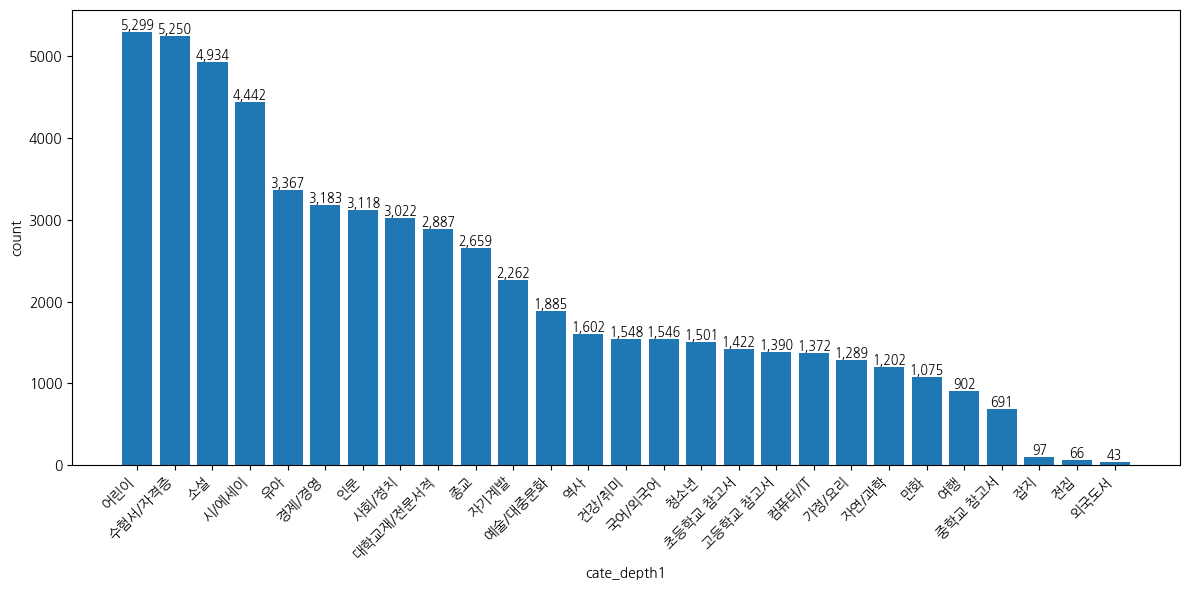

In [25]:
import matplotlib.pyplot as plt

result = df.explode('cate_depth1').groupby('cate_depth1').size().sort_values(ascending=False).reset_index()
result.columns = ['cate_depth1', 'count']

plt.figure(figsize=(12, 6))
bars = plt.bar(result['cate_depth1'], result['count'])

# 막대 위에 건수 표시
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

plt.xticks(rotation=45, ha='right')
plt.xlabel('cate_depth1')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [26]:
# 두 필드 합치기
df['combined'] = df['book_intro'].fillna('') + ' ' + df['pub_review'].fillna('')

# 합친 길이 분포 확인 (threshold 결정용)
df['combined_len'] = df['combined'].str.len()
print(df['combined_len'].describe(percentiles=[.25, .5, .75, .95, .99]))

count    47810.000000
mean      1922.758879
std       1474.287143
min         55.000000
25%        928.000000
50%       1566.000000
75%       2487.000000
95%       4580.100000
99%       7055.910000
max      44364.000000
Name: combined_len, dtype: float64


In [27]:
# 데이터 길이 기준이 아니라 토큰 길이 기준으로 truncate 진행

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

df['token_len'] = df['combined'].apply(lambda x: len(tokenizer.encode(x)))
print(df['token_len'].describe(percentiles=[.75, .95, .99]))

# 초과하는 비율 확인
print(f"8192 초과 비율: {(df['token_len'] > 8192).mean():.2%}")

/home/jjeong3150/anaconda3/envs/book-curation/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8387 > 8192). Running this sequence through the model will result in indexing errors


count    47810.000000
mean      1029.461012
std        801.602287
min         29.000000
75%       1332.000000
95%       2479.550000
99%       3864.460000
max      23726.000000
Name: token_len, dtype: float64
8192 초과 비율: 0.04%


In [28]:
pd.set_option('display.max_colwidth', None)
df[df['token_len'] < 50][['title', 'book_intro','pub_review','combined']].head(10)

,title,book_intro,pub_review,combined
10803,"기막힌 모의고사 3종세트 - 신개념 9급 공무원 시험 대비,2012,국어 영어 한국사, 전3권",2012 기막힌 모의고사 3종세트(국어 영어 한국사) 입니다.,2012 기막힌 모의고사 3종세트(국어 영어 한국사) 입니다.,2012 기막힌 모의고사 3종세트(국어 영어 한국사) 입니다. 2012 기막힌 모의고사 3종세트(국어 영어 한국사) 입니다.
15251,대퍼즐 : 우리나라지도 - 한 눈에 보는 지도 퍼즐,"우리나라 지역의 위치와 여러 가지 국보, 특산물 등을 퍼즐로 맞추며 학습할 수 있습니다.",180조각,"우리나라 지역의 위치와 여러 가지 국보, 특산물 등을 퍼즐로 맞추며 학습할 수 있습니다. 180조각"
31055,황남기 공직선거법,- 독자대상 공무원시험 준비생 - 특징 최신판례와 법령 분석 반영 최근출제경향을 분석 반영,- 최신판례와 법령 완벽 분석 반영 - 최근출제경향을 완벽 분석 반영,- 독자대상 공무원시험 준비생 - 특징 최신판례와 법령 분석 반영 최근출제경향을 분석 반영 - 최신판례와 법령 완벽 분석 반영 - 최근출제경향을 완벽 분석 반영
46308,"민법 엣센스2010 - 채권법, 2010","- 독자대상 공인노무사, 감정평가사 수험생 - 구성 이론 판례",황보수정 교수님의 민법 엣센스(채권법)입니다.,"- 독자대상 공인노무사, 감정평가사 수험생 - 구성 이론 판례 황보수정 교수님의 민법 엣센스(채권법)입니다."
49605,국가수준 학업성취도평가 기출문제 중3 - 2009,2008.2007.2006 년도 3개년 기출 문제 수록 - 출판사 제공,2008.2007.2006 년도 3개년 기출 문제 수록,2008.2007.2006 년도 3개년 기출 문제 수록 - 출판사 제공 2008.2007.2006 년도 3개년 기출 문제 수록
88968,잃어버린 꿈에 피는 꽃,오랫동안 잃어버린 꿈에서도 꽃을 피울 수 있음을 노래하고 싶어서.,사파일지언정 참에 이르를 수 있음을 노래하다.,오랫동안 잃어버린 꿈에서도 꽃을 피울 수 있음을 노래하고 싶어서. 사파일지언정 참에 이르를 수 있음을 노래하다.
89980,나는 치과의사다,"치과의사에서 CEO까지- 한국인에게 꼭 맞는 임플란트를 만들어낸 원동력! 투명한 경영, 사람 중심의 진료철학을 바탕으로 했기 때문입니다.",.,"치과의사에서 CEO까지- 한국인에게 꼭 맞는 임플란트를 만들어낸 원동력! 투명한 경영, 사람 중심의 진료철학을 바탕으로 했기 때문입니다. ."


In [29]:
# 두 필드 합치기
df['combined'] = df['book_intro'].fillna('') + '|' + df['pub_review'].fillna('')

# 합친 길이 분포 확인 (threshold 결정용)
df['combined_len'] = df['combined'].str.len()
print(df['combined_len'].describe(percentiles=[.25, .5, .75, .95, .99]))

count    47810.000000
mean      1922.758879
std       1474.287143
min         55.000000
25%        928.000000
50%       1566.000000
75%       2487.000000
95%       4580.100000
99%       7055.910000
max      44364.000000
Name: combined_len, dtype: float64


## combinded 기준 truncate
- bge-m3는 최대 8192 토큰까지 처리 가능
- 현재 데이터는 bge-m3가 사실상 모든 데이터 커버 가능
- 그래서 0.04%만 지우는 걸로 진행

In [30]:
df = df[df['token_len'] <= 8192]  # 19건만 제거

### author 분류 확인

In [31]:
df[df['author'].apply(lambda x: isinstance(x, list) and len(x) == 0)][['isbn', 'title', 'author', 'translator', 'supervisor', 'ori_author']].head(50)

,isbn,title,author,translator,supervisor,ori_author
124,9788957593042,농장의 하루,[],[양진성],[],양진성 역
288,9791156750598,엄마 배 속에 뭐가 들어 있지? - 가족이 함께 보는 레아 성장 그림책 2,[],[이승수],[],이승수 역
410,9788962621716,"마이 버자이너 - 세상의 기원, 내 몸 안의 우주",[],[김명남],[],김명남 역
668,9788963601458,샌드필즈의 추억 - 마틴 로이드 존스 첫 목회의 기록 = Memories of Sandfields,[],[전의우],[],전의우 역
702,9788960523357,브레이크 에이지 3,[],[김완],[],김완 역
928,9791134890636,세계 제일 별난 과학사전,[],[],[사마키 타케오],사마키 타케오 감수
965,9788997728404,똑똑해지는 약 - 꾸러기 메메 시리즈 1,[],[이순영],[],이순영 역
1079,9788952787996,물의 아이들 - 랜드 클래식 30,[],[김영선],[],김영선 역
1687,9788963720579,고통은 계속되지 않는다 - 페디엠 28 = Trouble don't last,[],[홍한별],[],홍한별 역
2142,9788942817238,새벽 강가에 해오라기 우는 소리 하,[],[김동욱],[],김동욱 역


In [32]:
df[df['ori_author'].str.contains(r',\s*(만화|기획|제작|촬영|편집)', na=False)]['ori_author'].head(50)

/tmp/ipykernel_72289/2933573200.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[df['ori_author'].str.contains(r',\s*(만화|기획|제작|촬영|편집)', na=False)]['ori_author'].head(50)


8720                           지금,  만화 발간위원회  저
28403    MBC프로덕션 뽀뽀뽀팀 기획, 제작 / KB국민은행연구소 연구, 감수
37281                    우리누리 글, 기획 / 그리미 카툰 그림
52274                                  황경아, 편집부
Name: ori_author, dtype: str

In [33]:
keywords = ['글', '그림', '만화', '기획', '제작']
mask = df['ori_author'].apply(lambda x: any(kw in x for kw in keywords) if isinstance(x, str) else False)
df[mask][['author', 'translator', 'supervisor', 'ori_author']].head(50)

,author,translator,supervisor,ori_author
28,"[이상교, 김세현]",[],[],이상교 글/김세현 그림
60,[제프 존스],[],[],제프 존스 글
61,[모리야마 다이스케],[],[],모리야마 다이스케 글그림
72,[김세현],[박수밀],[],박수밀 역 / 김세현 그림
76,[베이비버스],[김영미],[],베이비버스 글그림/김영미 역
81,"[앙투안 드 생텍쥐페리 원, 이재은]",[],[],앙투안 드 생텍쥐페리 원저/이재은 그림
89,[파스칼 에스테롱],[],[],"파스칼 에스테롱 글, 그림"
118,"[이호백, 운비, 미나래]",[],[],이호백 글/운비 그림/미나래 기획
121,[안자이 미즈마루],[김영희],[],안자이 미즈마루 글그림/김영희 역
138,[최민지],[],[],최민지 글그림


In [34]:
# 쉼표 뒤에 역할 태그가 오는 패턴 확인
pattern = r',\s*(저|공저|편저|역|공역|편역|감수)'
df[df['ori_author'].apply(lambda x: bool(re.search(pattern, x)) if isinstance(x, str) else False)]['author']

998                              [국립중앙박물관]
20640             [실제 블라인드 면접관, 역량연구 금계학당]
28403         [MBC프로덕션 뽀뽀뽀팀, KB국민은행연구소 연구]
58462            [안드레아스 J. 쾨스텐버거, 저스틴 테일러]
70197                             [고혜진 구성]
72635     [조니 롱, 빌 가드너, 저스틴 브라운, 이충만, 김지우]
88548                          [스테이시 아디만도]
100496         [이기훈, 저우쥔위, 권보드래, 옌싱루, 함동주]
Name: author, dtype: object

In [35]:
df[df['author'].apply(lambda x: isinstance(x, list) and len(x) >= 4)][['isbn', 'title', 'author']].head(20)

,isbn,title,author
1,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]"
169,9791196401023,천연균에서 찾은 오래된 미래 - 시골빵집 타루마리와 이우학교 대담집,"[와타나베 이타루, 와타나베 마리코, 우경윤, 김철원]"
226,9791125309734,LISTENING BUDDY 리스닝버디 2 - 초등학생의 영어 친구,"[한정은, 백수자, 권혜진, 송진아]"
278,9788927196204,어린이 지식클립 시리즈 1~3권 세트,"[류혜인, 정재은, 이진아, 이경석, 신동민]"
290,9788928302666,신통방통 길이 재기 - 방통 수학 8,"[서지원, 혜경, 심창국, 주미]"
310,9788991197442,한국 현대사 이해 - 새로운 세대의 새 역사교과서,"[김광동, 김창근, 유광호, 유석춘 등]"
334,9788963474205,"제2공항 너머, 시민의 대안","[김학준, 이희준, 노민규, 정영신]"
375,9788959428694,2020 ERP 정보관리사 인사 1급 - 20 ERP 정보관리사 - 삼일인포마인\r\n,"[신춘우, 조유근, 김진우, 임상종]"
379,9791187437000,스마트폰 활용지도사 - 스마트폰 활용교육 제대로 배우고 익히면 인생이 즐거워진다,"[안용병, 변점옥, 김미경, 박서영 등]"
486,9788984054790,경제의 교양을 읽는다 : 고전편 - 의 교양을 읽는다 시리즈,"[홍훈, 김진방, 박만섭, 류동민, 박종현]"


In [36]:
# 빈 리스트 비율 확인
for col in ['author', 'translator', 'supervisor']:
    empty = df[col].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
    none = df[col].apply(lambda x: not isinstance(x, list)).sum()
    print(f"{col} - 빈 리스트: {empty}, 리스트 아닌 값: {none}")

author - 빈 리스트: 674, 리스트 아닌 값: 0
translator - 빈 리스트: 37916, 리스트 아닌 값: 0
supervisor - 빈 리스트: 46736, 리스트 아닌 값: 0


In [37]:
df[df['ori_author'].str.contains('국립중앙박물관', na=False)][['title', 'ori_author', 'author', 'translator', 'supervisor']]

,title,ori_author,author,translator,supervisor
998,국립중앙박물관 가이드북 - Official Guide to the National Museum of Korea,"국립중앙박물관 편저, 감수",[국립중앙박물관],[],[국립중앙박물관]
3933,부석사 괘불,국립중앙박물관 편,[국립중앙박물관],[],[]


### KDC 코드 매핑
- `Offline_json_20260401/` 디렉토리 내 JSON 파일들을 루프로 스트리밍 파싱합니다.
- 파일 크기가 크기 때문에 줄 단위로 읽어 메모리 사용을 최소화합니다.
- 딕셔너리 생성 후 `df['isbn'].map()`으로 KDC 컬럼을 추가합니다.

In [38]:
import re
import glob
from tqdm.auto import tqdm

# ISBN-13은 항상 978 또는 979로 시작하는 13자리
_ISBN13 = re.compile(r'(?:978|979)\d{10}')
_KDC    = re.compile(r'"kdc"\s*:\s*(?:\[\s*)?"([^"]*)"')


def build_isbn_kdc_map(filepaths):
    """
    JSON 파일(들)을 줄 단위 스트리밍으로 파싱해 ISBN-13 → KDC 딕셔너리를 반환합니다.
    - isbn 단일/배열, 볼륨 접미사(예: '(2)') 모두 처리
    - kdc 단일/배열 모두 처리
    - 같은 ISBN에 KDC 중복 시 먼저 등장한 값 유지
    """
    if isinstance(filepaths, str):
        filepaths = [filepaths]

    isbn_kdc = {}

    for filepath in tqdm(filepaths, desc='파일 처리', unit='file'):
        current = {}
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                s = line.rstrip()
                indent = len(s) - len(s.lstrip())
                s = s.strip()

                # 들여쓰기 2 이하의 '{' → 새 레코드 경계: 직전 레코드 저장
                if indent <= 2 and '{' in s and not s.startswith('"'):
                    if current.get('kdc'):
                        for isbn13 in current.get('isbns', []):
                            isbn_kdc.setdefault(isbn13, current['kdc'])
                    current = {}

                if s:
                    # isbn 줄에서 978/979로 시작하는 13자리를 모두 추출
                    # → 단일/배열/볼륨접미사 구분 없이 한 번에 처리
                    if '"isbn"' in s:
                        for m in _ISBN13.finditer(s):
                            current.setdefault('isbns', []).append(m.group())

                    m = _KDC.search(s)
                    if m and 'kdc' not in current:
                        current['kdc'] = m.group(1)

    return isbn_kdc


In [39]:
BOOK_JSON_DIR = '../../data/raw/Offline_json_20260401'

filepaths = sorted(glob.glob(f'{BOOK_JSON_DIR}/*.json'))
print(f'파일 수: {len(filepaths)}')
for p in filepaths[:3]:
    print(' ', p)

isbn_kdc_map = build_isbn_kdc_map(filepaths)
print(f'\nISBN-KDC 매핑 수: {len(isbn_kdc_map):,}')


파일 수: 36
  ../../data/raw/Offline_json_20260401/Offline_0.json
  ../../data/raw/Offline_json_20260401/Offline_1.json
  ../../data/raw/Offline_json_20260401/Offline_10.json


파일 처리: 100%|██████████| 36/36 [02:26<00:00,  4.06s/file]


ISBN-KDC 매핑 수: 1,600,661


In [40]:
df['kdc'] = df['isbn'].astype(str).map(isbn_kdc_map)

matched = df['kdc'].notna().sum()
print(f'KDC 매핑 완료: {matched:,} / {len(df):,} ({matched/len(df)*100:.1f}%)')
df[['isbn', 'kdc']].head(10)


KDC 매핑 완료: 37,224 / 47,789 (77.9%)


,isbn,kdc
1,9788987835730,699.104
3,9788963717715,823.7
5,9791185860084,326.180911
7,9791189017057,NaN
11,9791193277225,NaN
13,9788933607817,581.3
15,9788997390205,005.11
16,9788995904961,220.4
17,9791157032068,199.1
18,9788952626882,NaN


In [41]:
# KDC 1자리 대분류 분포
df['kdc_top'] = df['kdc'].dropna().str[0]
df['kdc_top'].value_counts().sort_index()


kdc_top
0     1712
1     2052
2     1884
3     8755
4     1957
5     3692
6     1955
7     2553
8    10356
9     2308
Name: count, dtype: int64

In [42]:
# kdc 앞 정수 세 자리 추출
df['kdc_code'] = df['kdc'].apply(
    lambda x: str(x).split('.')[0].zfill(3)[:3] if pd.notna(x) and str(x).strip() != '' else None
)

# KDC6.csv 로드 및 매핑
kdc6 = pd.read_csv('../../data/raw/KDC6.csv', dtype={'kdc_code': str})

df = df.merge(
    kdc6[['kdc_code', 'kdc_depth1', 'kdc_depth2', 'kdc_depth3']],
    on='kdc_code',
    how='left'
)

matched = df['kdc_depth1'].notna().sum()
print(f'KDC depth 매핑 완료: {matched:,} / {len(df):,} ({matched/len(df)*100:.1f}%)')
df[['kdc', 'kdc_code', 'kdc_depth1', 'kdc_depth2', 'kdc_depth3']].head(10)

KDC depth 매핑 완료: 37,224 / 47,789 (77.9%)


,kdc,kdc_code,kdc_depth1,kdc_depth2,kdc_depth3
0,699.104,699,예술,"오락, 스포츠",기타 오락 및 레저스포츠
1,823.7,823,문학,중국문학,소설
2,326.180911,326,사회과학,경제학,"상업, 교통, 통신"
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,581.3,581,기술과학,제조업,금속 제조 및 가공업
6,005.11,005,총류,NaN,"프로그래밍, 프로그램, 데이터"
7,220.4,220,종교,불교,NaN
8,199.1,199,철학,"윤리학, 도덕철학","도덕훈, 교훈"
9,NaN,NaN,NaN,NaN,NaN


### 데이터 최종 출력

In [43]:
pd.set_option('display.max_colwidth', 100)  # 컬럼 너비 제한

cols = ['isbn', 'title', 'author', 'translator', 'supervisor', 'publisher', 'publish_year', 'publish_date_dt', 'page', 'combined', 'kdc', 'kdc_code', 'kdc_depth1', 'kdc_depth2', 'kdc_depth3', 'cate_depth1', 'ori_cover_s']
df = df[cols]
df = df.rename(columns={'combined': 'book_intro'})

print(f'레코드 수: {len(df):,}')
print(f'컬럼 수: {len(df.columns)}')

df.head(5)

레코드 수: 47,789
컬럼 수: 17


,isbn,title,author,translator,supervisor,publisher,publish_year,publish_date_dt,page,book_intro,kdc,kdc_code,kdc_depth1,kdc_depth2,kdc_depth3,cate_depth1,ori_cover_s
0,9788987835730,직장인을 위한 주말 가족 산행기 100선 2,"[이상훈, 고광문, 이은빈, 이은찬]",[],[],화담,2014,2014-03-24T00:00:00+09:00,304,아빠와 엄마 그리고 두 아이들의 산행기는 계속된다. 여전히 주말이면 산을 찾아 가족은 떠날 채비를 한다. 국내 곳곳을 돌아다니며 아이들이 자라는 모습을 산과 함께 했고 지난...,699.104,699,예술,"오락, 스포츠",기타 오락 및 레저스포츠,"[여행, 건강/취미]",https://image.aladin.co.kr/product/3917/39/cover500/8987835731_1.jpg
1,9788963717715,부요황후 1,[천하귀원],[김지혜],[],파란썸 (파란미디어),2020,2020-07-14T00:00:00+09:00,420,"중국 누적 조회 수 100억 돌파, 드라마 부요황후 원작 소설 유머 넘치는 문장과 탄탄한 이야기, 끊임없는 상상력이 돋보이는 부요황후 . 작가 천하귀원에게 2012년 진강시...",823.7,823,문학,중국문학,소설,[소설],https://image.aladin.co.kr/product/24410/85/cover500/8963717712_1.jpg
2,9791185860084,"시장이 두근두근 2 - 대전, 대구, 광주, 부산, 제주",[이희준],[],[],이야기나무,2015,2015-07-07T00:00:00+09:00,360,"서울부터 수원, 인천, 강원, 대전, 대구, 광주, 부산, 그리고 제주도까지 전국에 흩어진 435곳의 전통시장을 다니며 기록하면서 언제나 즐거웠던 것만은 아니었지만 지나고 ...",326.180911,326,사회과학,경제학,"상업, 교통, 통신",[여행],https://image.aladin.co.kr/product/6266/95/cover500/k982433732_1.jpg
3,9791189017057,초등학생을 위한 영재수학의 지름길 초급 하,[중국사천대학],[이수진],[멘사수학연구소],씨실과날실,2019,2019-01-30T00:00:00+09:00,204,지난 20여년 동안 국내의 수많은 선생님들과 우수한 학생들에게 사랑 받아온 올림피아드 수학의 지름길시리즈가 2019년을 맞아 국내에 맞추어 최신 신경향 사고력 문제와 국내외...,NaN,NaN,NaN,NaN,NaN,[초등학교 참고서],https://image.aladin.co.kr/product/18015/36/cover500/k772534741_1.jpg
4,9791193277225,초등 저학년 교과연계 문해력 필독서 세트,[편집부],[],[],춘희네책방,2025,2025-02-18T00:00:00+09:00,0,초등학교 1 2학년 교과과정 연계 도서 세트입니다.|1. 블랙팬서 자신감 우정 성장 국어 2-1 8. 다양한 작품을 감상해요 국어 2-2 1. 장면을 떠올리며 국어 2-2 ...,NaN,NaN,NaN,NaN,NaN,[어린이],https://image.aladin.co.kr/product/35898/84/cover500/k362037089_1.jpg


### 데이터 확인

In [44]:
result = df.explode('cate_depth1').groupby('cate_depth1').size().sort_values(ascending=False).reset_index()
result.columns = ['cate_depth1', 'count']
result

,cate_depth1,count
0,어린이,5299
1,수험서/자격증,5248
2,소설,4930
3,시/에세이,4435
4,유아,3367
5,경제/경영,3183
6,인문,3116
7,사회/정치,3020
8,대학교재/전문서적,2884
9,종교,2658


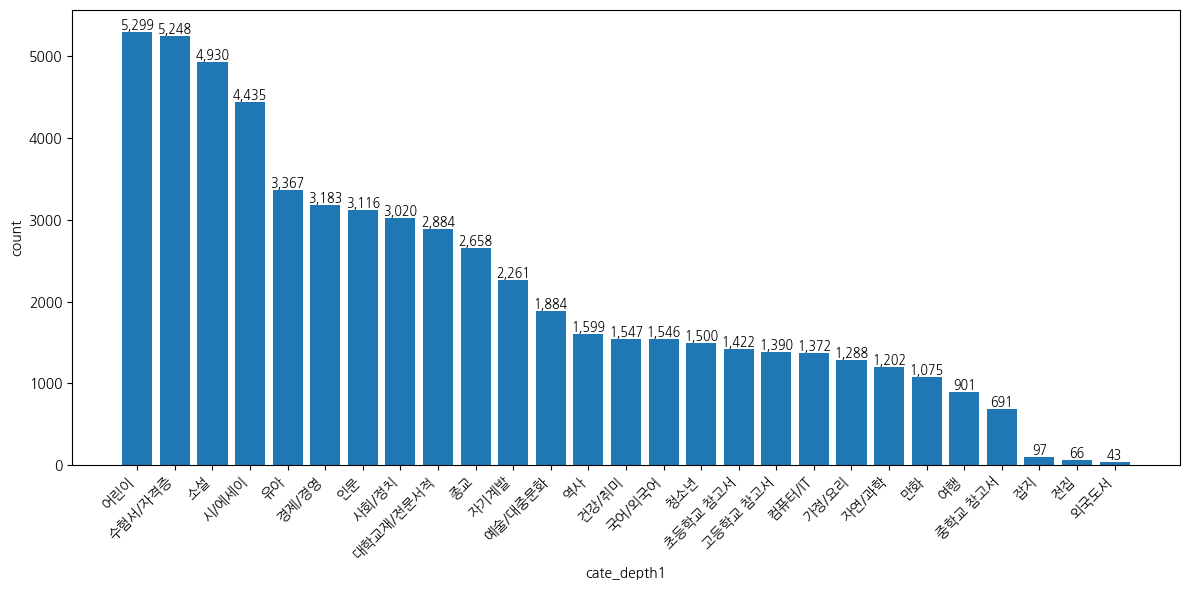

In [45]:
import matplotlib.pyplot as plt

result = df.explode('cate_depth1').groupby('cate_depth1').size().sort_values(ascending=False).reset_index()
result.columns = ['cate_depth1', 'count']

plt.figure(figsize=(12, 6))
bars = plt.bar(result['cate_depth1'], result['count'])

# 막대 위에 건수 표시
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

plt.xticks(rotation=45, ha='right')
plt.xlabel('cate_depth1')
plt.ylabel('count')
plt.tight_layout()
plt.show()

#### 기본 품질 확인

In [46]:
# KDC 없는 행 샘플 — 어떤 책들이 매핑 안 됐는지 확인
df[df['kdc'].isna()][['isbn', 'title', 'publisher', 'cate_depth1']].sample(20, random_state=42)

,isbn,title,publisher,cate_depth1
16663,9791165333256,"2023 정호국어 - 공무원, 군무원, 법원직, 경찰직, 국회직, 세무직, 관세직, 기술직",하이앤북,[수험서/자격증]
13171,9791189712358,아이랑 이야기하며 함께 보는 동화책 1,피치마켓,[어린이]
30889,9791159625176,LawMan 형법 법행기출해설,윌비스,[수험서/자격증]
36852,9788926991107,"해법 수학 1학년 - 2014 10월호,스토리텔링 학습,시험대비 강화",천재교육,[초등학교 참고서]
17975,9791125955795,해법수학 4-2(2호) (2021년용) - 해법 수학 2학기 2호 (2022년용),천재교육(학원),[초등학교 참고서]
18410,9791190752015,"바질 Basil : V.12 기후위기, 생명 [2020] - Earth Life Guide 지구생활안내서",윌든,[잡지]
1374,9791171101771,2025 변리사 SHARE 저작권법 - 변리사시험대비,에듀비,[수험서/자격증]
33663,9788934922483,우리 몸은 거짓말하지 않는다,김영사,[건강/취미]
9236,9791157491513,샘의 새로운 시작,어썸키즈,[유아]
11757,9791130693279,만화 모든 게 착각이었다 2,다산코믹스,[만화]


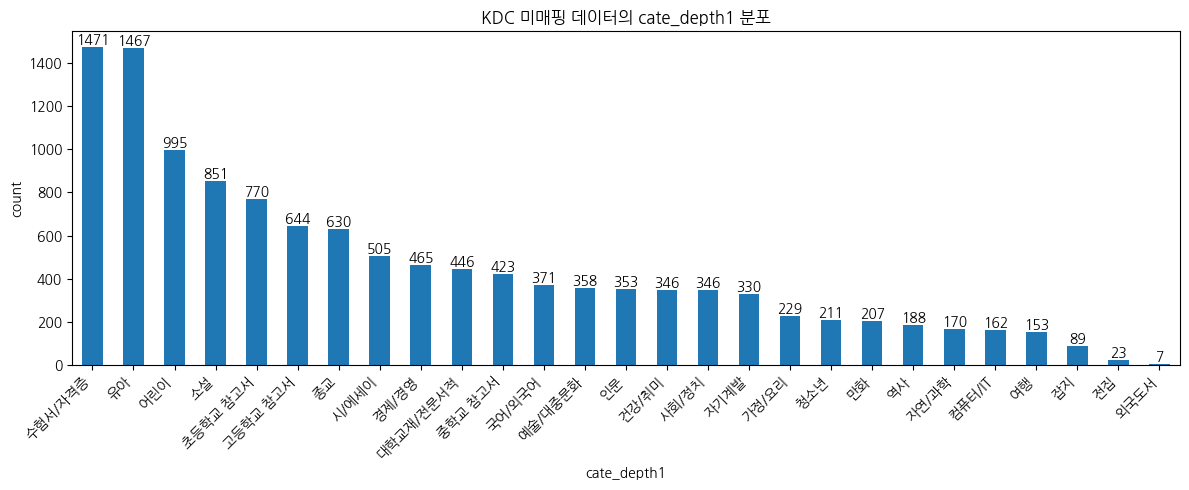

In [47]:
ax = (
    df[df['kdc'].isna()]
    ['cate_depth1']
    .explode()
    .value_counts()
    .plot(kind='bar', figsize=(12, 5), title='KDC 미매핑 데이터의 cate_depth1 분포')
)

ax.set_xlabel('cate_depth1')
ax.set_ylabel('count')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

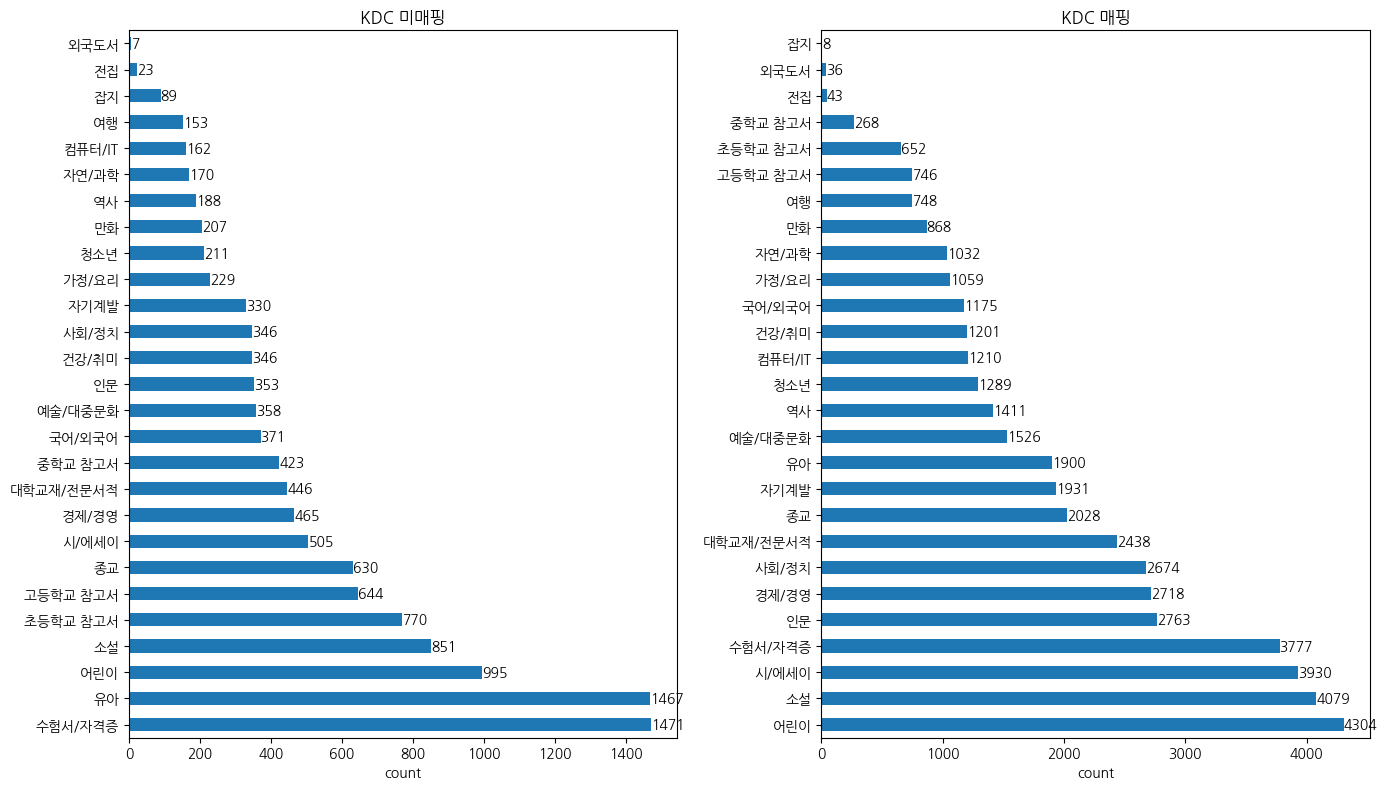

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, mask, title in [
    (axes[0], df['kdc'].isna(),  'KDC 미매핑'),
    (axes[1], df['kdc'].notna(), 'KDC 매핑'),
]:
    counts = df[mask]['cate_depth1'].explode().value_counts()
    counts.plot(kind='barh', ax=ax, title=title)
    ax.set_xlabel('count')
    ax.set_ylabel('')
    ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

In [49]:
import subprocess

def find_raw_record(filepaths, isbn, context=30):
    """ISBN으로 원본 레코드를 grep으로 찾아 전후 context 줄을 출력합니다."""
    for filepath in filepaths:
        result = subprocess.run(
            ['grep', '-n', f'-B{context}', f'-A{context}', isbn, filepath],
            capture_output=True, text=True
        )
        if result.stdout:
            print(f"=== {filepath.split('/')[-1]} ===")
            print(result.stdout[:3000])
            return
    print(f"{isbn} 파일에 없음")

# 매핑 안 된 ISBN 하나 골라서 확인
sample_isbn = df[df['kdc'].isna()]['isbn'].astype(str).iloc[0]
print(f"검색 ISBN: {sample_isbn}")
find_raw_record(filepaths, sample_isbn)


검색 ISBN: 9791189017057
9791189017057 파일에 없음


In [50]:
df[df['kdc'].str.startswith('259')]

,isbn,title,author,translator,supervisor,publisher,publish_year,publish_date_dt,page,book_intro,kdc,kdc_code,kdc_depth1,kdc_depth2,kdc_depth3,cate_depth1,ori_cover_s
8059,9791185134611,민족비전 정신수련법,[정재승],[],[권태훈],책미래,2020,2020-08-05T00:00:00+09:00,472,"우리 겨레의 얼 닦음을 다시 찾아서 이 책은 봉우 권태훈 선생님(1900-1994)의 한민족 비전 정신수련법에 대한 가르침을 정리한 것이다, 가르침의 내용은 봉우 선생님의 ...",259,259,종교,천도교,"단군교, 대종교",[인문],https://image.aladin.co.kr/product/24788/49/cover500/k702631735_1.jpg
19591,9788998502614,단재 정훈모 전집 3권,"[정훈모, 조준희]",[유영인],[],아라,2015,2015-05-01T00:00:00+09:00,423,"본 책은 총 3권으로, 제1권은 정훈모가 체계화한 경전인 천부경?삼일신고?성경팔리를 최초로 완역한 것이다. 제2권은 정훈모의 교리서와 역사서로서 진리문답, 천을선학경, 그리...",259,259,종교,천도교,"단군교, 대종교",[종교],https://image.aladin.co.kr/product/5669/48/cover500/8998502615_1.jpg
40871,9788965114314,천부경,[신지윤],[],[],시간의물레,2023,2023-03-31T00:00:00+09:00,412,"그동안 천부경을 설명한 책은 많았으나, 참전계경을 중심으로 한 책은 없다. 이 책에는 우리 겨레의 정신과 가치관, 그리고 삶의 철학을 상징하는 3가지 경전을 풀이하여 실었다...",259.3,259,종교,천도교,"단군교, 대종교",[종교],https://image.aladin.co.kr/product/31487/3/cover500/8965114314_1.jpg
46442,9788996630012,천부경 삼일신고,[도암],[],[],삼신출판사,2011,2011-08-29T00:00:00+09:00,280,우리 모두가 진인들인데 지금처럼 전염성 탐욕에 물들어 헤어나지 못하면 동물본성으로 사는 것이니 하루한번 아니 한달에 한번 이라도 배려하고 나누는 선덕을 쌓을 때 사람노릇하고...,259.3,259,종교,천도교,"단군교, 대종교","[인문, 종교]",https://image.aladin.co.kr/product/1417/78/cover500/8996630012_1.jpg


In [51]:
# for isbn in df[df['kdc'].isna()]['isbn'].astype(str).iloc[:10]:
#     print(f"\n{'='*60}")
#     find_raw_record(filepaths, isbn)

In [52]:
# 결측치
display(df.isnull().sum())

# 중복 ISBN
display(df['isbn'].duplicated().sum())

# 전체 shape
display(df.shape)

isbn                   0
title                  0
author                 0
translator             0
supervisor             0
publisher              0
publish_year           0
publish_date_dt        0
page                   0
book_intro             0
kdc                10565
kdc_code           10565
kdc_depth1         10565
kdc_depth2         13672
kdc_depth3         16687
cate_depth1           38
ori_cover_s          162
dtype: int64

np.int64(0)

(47789, 17)

In [53]:
df = df[df['kdc'].notna() & df['cate_depth1'].notna()]
print(f"남은 데이터: {len(df):,}건")

남은 데이터: 37,202건


#### book_intro 결측 비율 및 길이 분포 확인

In [54]:
# simple_intro, book_intro 결측 비율
# → 이게 비어있으면 벡터 품질이 낮아짐
df['book_intro'].isnull().mean()

np.float64(0.0)

In [55]:

# 텍스트 길이 분포
df['book_intro'].dropna().apply(len).describe()

count    37202.000000
mean      2045.691898
std       1453.298556
min         62.000000
25%       1031.000000
50%       1697.000000
75%       2651.000000
max      15752.000000
Name: book_intro, dtype: float64

## 데이터 적재

In [56]:
!pwd

/home/jjeong3150/work/aiffel_final_pjt/src/preprocess


In [57]:
import sys
import os
import uuid
import math
from tqdm import tqdm
from qdrant_client.models import PointStruct

sys.path.insert(0, os.path.abspath('../..'))

from src.db.qdrant import QdrantDB
from src.embedding.embedder import LocalEmbedder

In [58]:
embedder = LocalEmbedder()
db = QdrantDB(vector_size=1024)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 10558.06it/s]


In [59]:
# 컬렉션 리스트 확인

collections = db.get_collections().collections
c_list = []

for c in collections:
    c_list.append(c)
    info = db.client.get_collection(c.name)
    print(f"{c.name} — 벡터 수: {info.points_count:,}, 벡터 차원:{info.config.params.vectors.size}")

if len(c_list) == 0:
    print("저장된 collection이 없습니다.")

books_v1 — 벡터 수: 93,545, 벡터 차원:1024
books_v2 — 벡터 수: 1,408, 벡터 차원:1024


In [60]:
# 기존 컬렉션 삭제
db.delete_collection("books_v2")


🗑️ 컬렉션 삭제 완료: books_v2


In [61]:
COLLECTION_NAME = "books_v2"

embedder = LocalEmbedder()
db = QdrantDB(vector_size=1024)

existing = [c.name for c in db.get_collections().collections]
if COLLECTION_NAME not in existing:
    db.create_collection(COLLECTION_NAME)
    db.create_payload_index(COLLECTION_NAME, "cate_depth1", "keyword")
    db.create_payload_index(COLLECTION_NAME, "publish_year", "integer")
    db.create_payload_index(COLLECTION_NAME, "author", "text")
    db.create_payload_index(COLLECTION_NAME, "title", "text")
    db.create_payload_index(COLLECTION_NAME, "kdc_code", "keyword")
    db.create_payload_index(COLLECTION_NAME, "kdc_depth1", "keyword")
    db.create_payload_index(COLLECTION_NAME, "kdc_depth2", "keyword")
    db.create_payload_index(COLLECTION_NAME, "kdc_depth3", "keyword")
else:
    print(f"컬렉션 이미 존재: {COLLECTION_NAME}")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 11220.16it/s]


✅ 컬렉션 생성 완료: books_v2
✅ 인덱스 생성 완료: cate_depth1 (keyword)
✅ 인덱스 생성 완료: publish_year (integer)
✅ 인덱스 생성 완료: author (text)
✅ 인덱스 생성 완료: title (text)
✅ 인덱스 생성 완료: kdc_code (keyword)
✅ 인덱스 생성 완료: kdc_depth1 (keyword)
✅ 인덱스 생성 완료: kdc_depth2 (keyword)
✅ 인덱스 생성 완료: kdc_depth3 (keyword)


In [62]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU 없음")
print(embedder.model.device)

True
NVIDIA GeForce RTX 4080 SUPER
cuda:0


In [63]:
import io
import contextlib

BATCH_SIZE = 64

def to_payload_val(v):
    if isinstance(v, float) and math.isnan(v):
        return None
    return v

records = df.to_dict('records')

for i in tqdm(range(0, len(records), BATCH_SIZE), desc="Qdrant 적재"):
    batch = records[i:i + BATCH_SIZE]
    vectors = embedder.embed_batch([r['book_intro'] for r in batch])

    points = [
        PointStruct(
            id=str(uuid.uuid5(uuid.NAMESPACE_DNS, str(row["isbn"]))),
            vector=vectors[j],
            payload={
                "isbn":         row["isbn"],
                "title":        row["title"],
                "author":       row["author"],
                "translator":   row["translator"],
                "supervisor":   row["supervisor"],
                "publisher":    to_payload_val(row["publisher"]),
                "publish_year": int(row["publish_year"]),
                "publish_date": to_payload_val(row["publish_date_dt"]),
                "page":         int(row["page"]),
                "book_intro":   row["book_intro"],
                "kdc":          to_payload_val(row.get("kdc")),
                "kdc_code":     to_payload_val(row.get("kdc_code")),
                "kdc_depth1":   to_payload_val(row.get("kdc_depth1")),
                "kdc_depth2":   to_payload_val(row.get("kdc_depth2")),
                "kdc_depth3":   to_payload_val(row.get("kdc_depth3")),
                "cate_depth1":  row["cate_depth1"],
                "cover_url":    to_payload_val(row["ori_cover_s"]),
            }
        )
        for j, row in enumerate(batch)
    ]

    with contextlib.redirect_stdout(io.StringIO()):
        db.insert(COLLECTION_NAME, points, id_field="isbn")

print(f"\n총 {len(records):,}건 적재 완료")

Qdrant 적재:  11%|█▏        | 66/582 [3:24:43<26:40:34, 186.11s/it]


ResponseHandlingException: The write operation timed out

### 데이터 적재 확인

In [ ]:
info = db.client.get_collection(COLLECTION_NAME)
print(f"컬렉션: {COLLECTION_NAME}")
print(f"저장된 벡터 수: {info.points_count:,}")
print(f"벡터 차원: {info.config.params.vectors.size}")

In [ ]:
# 1. 벡터 수 확인
info = db.client.get_collection(COLLECTION_NAME)
print(f"저장된 벡터 수: {info.points_count:,}")

In [ ]:
# 2. 샘플 데이터 확인 (scroll)
results, _ = db.client.scroll(
    collection_name=COLLECTION_NAME,
    limit=3,
    with_payload=True,
    with_vectors=False
)
for r in results:
    print(r.id, r.payload["title"], r.payload["author"])

In [ ]:
# 3. 실제 유사도 검색 테스트
query = "이집트 관련 책"
query_vector = embedder.embed(query)
results = db.search(COLLECTION_NAME, query_vector, limit=5, threshold=0.5)
for r in results:
    print(f"[{r.score:.3f}] {r.payload['title']} / {r.payload['author']}")

In [ ]:
query = "미국 자본주의 관련 책"
query_vector = embedder.embed(query)
results = db.search(COLLECTION_NAME, query_vector, limit=5, threshold=0.5)
for r in results:
    print(f"[{r.score:.3f}] {r.payload['title']} / {r.payload['author']}")
    print(f"  {r.payload['book_intro'][:100]}...")
    print()